In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


In [2]:
CHECKPOINT_PATH = "sam_vit_b.pth"   # path to your SAM checkpoint
MODEL_TYPE = "vit_b"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device)

predictor = SamPredictor(sam)


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

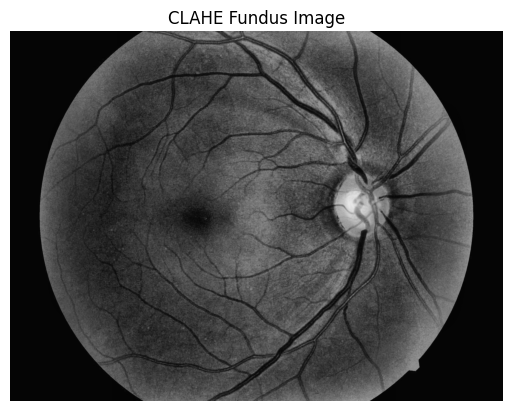

In [5]:
image_path = "inferior (4).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


In [6]:
predictor.set_image(image_rgb)


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

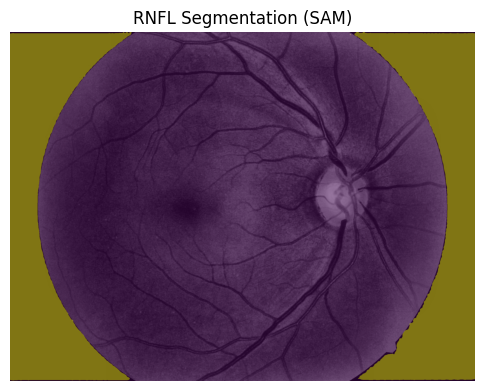

In [7]:
predictor.set_image(image_rgb)
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


In [8]:
predictor.set_image(image_rgb)


In [9]:
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground


In [10]:
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])


In [11]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

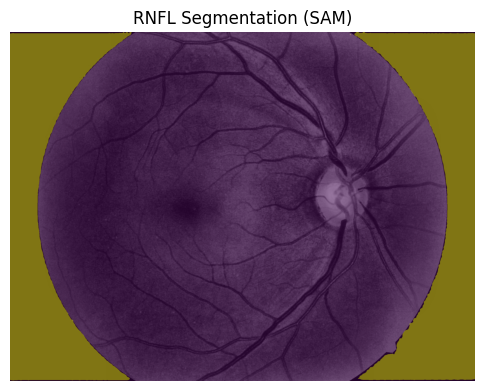

In [12]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


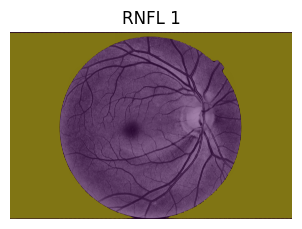

In [31]:
image_paths = [
    "inferior (2).jpg"
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


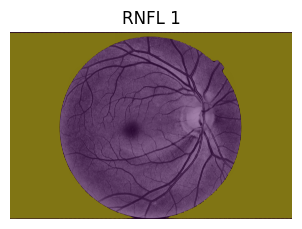

In [31]:
image_paths = [
    "inferior (2).jpg"
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


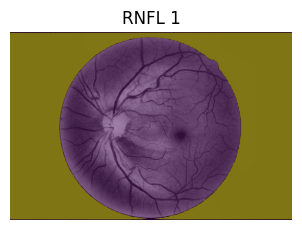

In [32]:
image_paths = [
    "inferior (3).jpg"
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


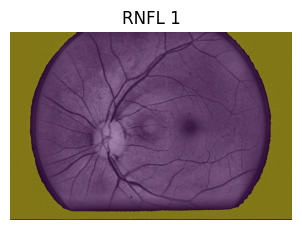

In [15]:
image_paths = [
    "superior (4).jpg"
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


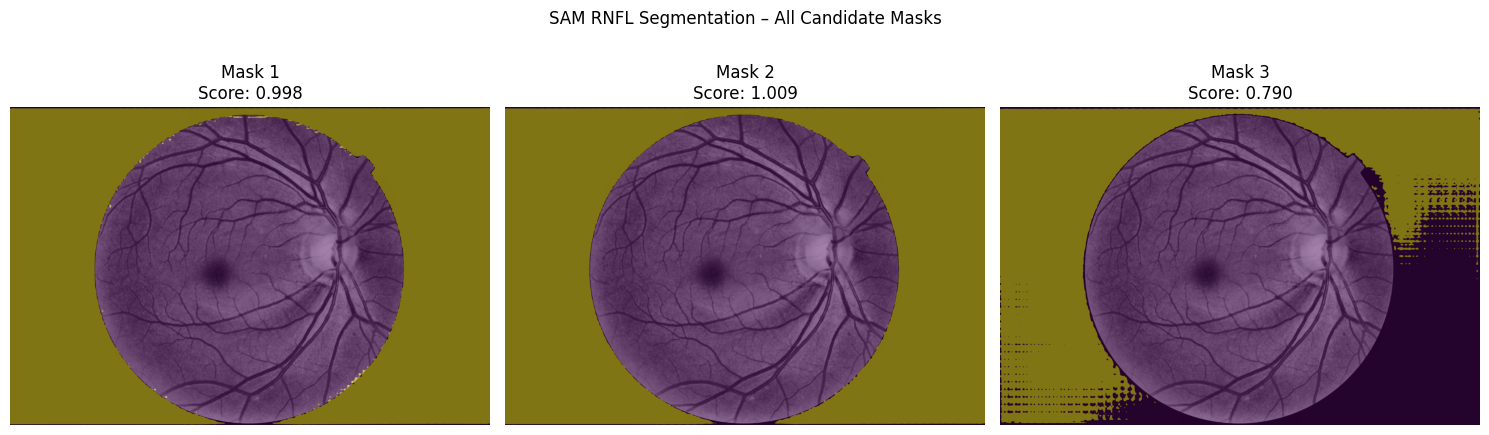

Image 1: Best mask = 2, Score = 1.009


In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- STEP 1: Image paths --------
image_paths = [
    "inferior (2).jpg"
]

# -------- STEP 2: Loop through images --------
for i, image_path in enumerate(image_paths):

    # -------- STEP 3: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 4: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 5: RNFL prompt points --------
    # Foreground = RNFL
    # Background = Non-RNFL (close to RNFL boundary)
    input_points = np.array([
        [400, 120],   # RNFL
        [450, 140],   # RNFL
        [430, 200]    # Background (important)
    ])

    input_labels = np.array([1, 1, 0])

    # -------- STEP 6: SAM prediction --------
    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    # -------- STEP 7: Visualize ALL masks --------
    plt.figure(figsize=(15, 5))

    for j in range(len(masks)):
        plt.subplot(1, len(masks), j + 1)
        plt.imshow(image_rgb)
        plt.imshow(masks[j], alpha=0.5)
        plt.title(f"Mask {j+1}\nScore: {scores[j]:.3f}")
        plt.axis("off")

    plt.suptitle("SAM RNFL Segmentation – All Candidate Masks")
    plt.tight_layout()
    plt.show()

    # -------- STEP 8: Select best mask --------
    best_index = np.argmax(scores)
    best_mask = masks[best_index]

    # -------- STEP 9: Save all masks --------
    for j in range(len(masks)):
        out_name = f"rnfl_mask_img{i+1}_cand{j+1}.png"
        cv2.imwrite(out_name, (masks[j] * 255).astype(np.uint8))

    # -------- STEP 10: Save best mask --------
    best_out = f"rnfl_mask_img{i+1}_best.png"
    cv2.imwrite(best_out, (best_mask * 255).astype(np.uint8))

    print(f"Image {i+1}: Best mask = {best_index+1}, Score = {scores[best_index]:.3f}")


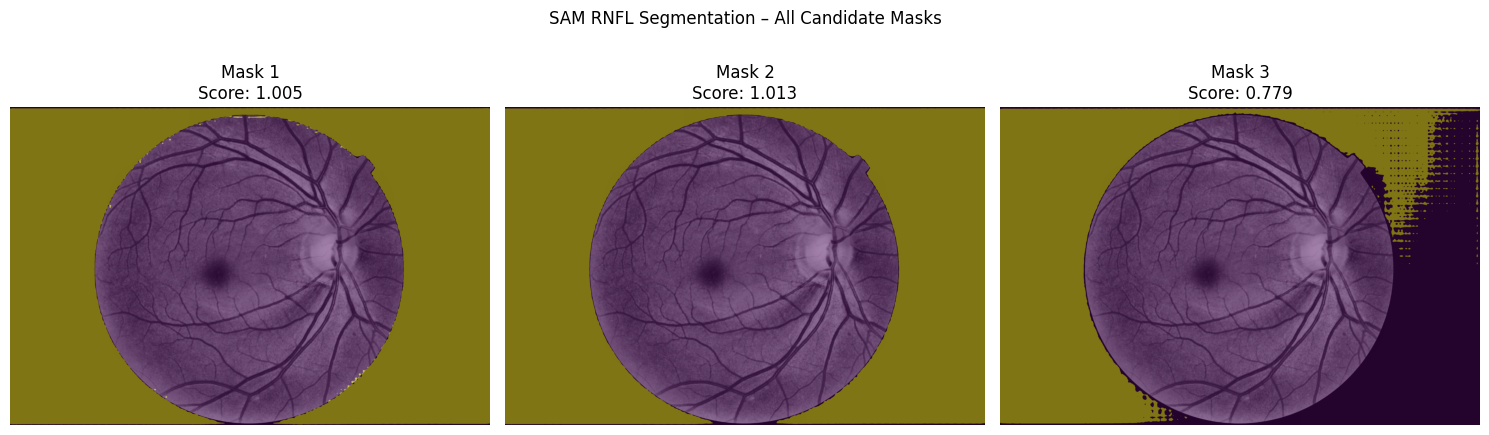

Image 1: Best mask = 2, Score = 1.013


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- STEP 1: Image paths --------
image_paths = [
    "inferior (2).jpg"
]

# -------- STEP 2: Loop through images --------
for i, image_path in enumerate(image_paths):

    # -------- STEP 3: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 4: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 5: RNFL prompt points --------
    # Foreground = RNFL
    # Background = Non-RNFL (close to RNFL boundary)
    input_points = np.array([
        [200, 120],   # RNFL
        [450, 540],   # RNFL
        [330, 200]    # Background (important)
    ])

    input_labels = np.array([1, 1, 0])

    # -------- STEP 6: SAM prediction --------
    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    # -------- STEP 7: Visualize ALL masks --------
    plt.figure(figsize=(15, 5))

    for j in range(len(masks)):
        plt.subplot(1, len(masks), j + 1)
        plt.imshow(image_rgb)
        plt.imshow(masks[j], alpha=0.5)
        plt.title(f"Mask {j+1}\nScore: {scores[j]:.3f}")
        plt.axis("off")

    plt.suptitle("SAM RNFL Segmentation – All Candidate Masks")
    plt.tight_layout()
    plt.show()

    # -------- STEP 8: Select best mask --------
    best_index = np.argmax(scores)
    best_mask = masks[best_index]

    # -------- STEP 9: Save all masks --------
    for j in range(len(masks)):
        out_name = f"rnfl_mask_img{i+1}_cand{j+1}.png"
        cv2.imwrite(out_name, (masks[j] * 255).astype(np.uint8))

    # -------- STEP 10: Save best mask --------
    best_out = f"rnfl_mask_img{i+1}_best.png"
    cv2.imwrite(best_out, (best_mask * 255).astype(np.uint8))

    print(f"Image {i+1}: Best mask = {best_index+1}, Score = {scores[best_index]:.3f}")


In [1]:
predictor.set_image(image_rgb)


NameError: name 'predictor' is not defined